# Biomechanical parameters — video vs. Optojump

Computes ground contact time, flight time, and step length from pose-based gait phase
predictions, then compares them to Optojump ground-truth measurements.

**Optojump filter:** only steps after the 20 m mark (`distance > 2000 cm`) are used
to avoid acceleration-phase artefacts.

**Predictions source:** TCN inference manifest (`stage6`).  Falls back to ground-truth
labels from the annotation CSV if the manifest is absent.

In [1]:
import json
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import ndarray

from experiments.gait_detection.config import ExperimentConfig
from src.gait.detection.detectors import KinematicDetector, XGBoostDetector
from src.gait.detection.postprocess import smooth_probs_argmax
from src.gait.gait_data.dataset import load_dataset_with_pose, VideoRecord
from src.gait.parameters.biomechanics import (
    gait_intervals,
    compute_cadence,
    compute_step_lengths,
    compute_joint_angles,
)

In [2]:
# Label source: "tcn" | "xgb" | "kinematic" | "annotations"
LABEL_SOURCE = "tcn"

# paths
TCN_MANIFEST   = "data/output/gait/pose_data/stage6/manifest.json"
XGB_MODEL_PATH = "data/output/gait/pose_data/stage3/checkpoints/model.pkl"
XGB_FEATURE_IDX = list(range(20))  # features 0–19 (as trained in stage3)

OPTOJUMP_CSV    = "data/input/optojump/optojump_output/parsed/optojump_basic.csv"
RUNNER_HEIGHT_M = 2.0
POSTPROCESS_WIN = 3    # window for TCN soft-label smoothing
MIN_DISTANCE_CM = 2000

In [3]:
os.chdir('..')

## Load pose data + predictions

In [4]:
_manifest_idx: dict | None = None
_xgb_detector: XGBoostDetector | None = None

def load_tcn_manifest():
    manifest_idx: dict = {}
    try:
        with open(TCN_MANIFEST) as f:
            manifest = json.load(f)
        manifest_idx = {r["video_path"]: r for r in manifest["records"]}
        print(f"Manifest loaded — {len(manifest_idx)} records, trial #{manifest['trial_id']}")
    except FileNotFoundError:
        if LABEL_SOURCE == "tcn":
            raise FileNotFoundError(f"TCN manifest not found: {TCN_MANIFEST}")
    return manifest_idx

def load_xgb_detector(path, feature_idx):
    return XGBoostDetector(path, feature_idx)

In [5]:
cfg = ExperimentConfig()
cfg.annotations_csv = "data/output/annotations/optojump/ml_training_dataset_clean.csv"

pairs = load_dataset_with_pose(cfg.annotations_csv, fps=cfg.fps)

## Compute per-video biomechanical parameters

In [6]:
def load_labels_tcn(rec: VideoRecord) -> ndarray:
    global _manifest_idx
    if _manifest_idx is None:
        _manifest_idx = load_tcn_manifest()
    entry = _manifest_idx[rec.video_path]
    probs = np.load(entry["probs_path"])
    return smooth_probs_argmax(probs, window=POSTPROCESS_WIN)



def load_labels_xgb(rec: VideoRecord) -> ndarray:
    global _xgb_detector
    if _xgb_detector is None:
        _xgb_detector = XGBoostDetector(XGB_MODEL_PATH, XGB_FEATURE_IDX)
    return _xgb_detector.predict(rec.features, cfg.fps)


def load_labels_kinematic(rec: VideoRecord) -> ndarray:
    return KinematicDetector().predict(rec.features, cfg.fps)


def load_labels_annotations(rec: VideoRecord) -> ndarray:
    return rec.labels

In [7]:
def _study_test(video_path: str) -> tuple[int, int]:
    path = Path(video_path)
    study_match = re.search(r"study_(\d+)", video_path)
    study_id = int(study_match.group(1)) if study_match else 0
    try:
        test_id = int(path.stem.split("_")[-1])
    except (ValueError, IndexError):
        test_id = 0
    return study_id, test_id

In [8]:
def make_bio_df(load_labels: callable) -> tuple[pd.DataFrame, dict]:
    results = []
    all_steps = {"contact": [], "flight": [], "length": []}

    for rec, pose_df in pairs:
        labels = load_labels(rec)

        study_id, test_id = _study_test(rec.video_path)
        meta = {"athlete": rec.athlete, "study_id": study_id, "test_id": test_id}

        ivs = gait_intervals(labels, fps=cfg.fps)
        cad = compute_cadence(labels, fps=cfg.fps)
        sl_df = compute_step_lengths(labels, pose_df, fps=cfg.fps, runner_height_m=RUNNER_HEIGHT_M)

        contact_segs = ivs["contact"][1:-1]
        flight_segs  = ivs["flight"][1:-1]
        sl_trimmed   = sl_df.iloc[1:-1]

        for key, source, col in [
            ("contact", contact_segs, "duration_s"),
            ("flight",  flight_segs,  "duration_s"),
        ]:
            step_df = pd.DataFrame(source).rename(columns={col: f"{key}_s"})
            all_steps[key].append(step_df.assign(**meta))

        all_steps["length"].append(sl_trimmed[["step_length_m"]].dropna().assign(**meta))

        gcts = [c["duration_s"] for c in contact_segs]
        flts = [f["duration_s"] for f in flight_segs]
        sls  = sl_trimmed["step_length_m"].dropna()

        results.append({
            **meta,
            "video_path": rec.video_path,
            "mean_gct_s": np.nanmean(gcts) if gcts else np.nan,
            "mean_flight_s": np.nanmean(flts) if flts else np.nan,
            "mean_step_length_m": np.nanmean(sls) if not sls.empty else np.nan,
            "cadence_spm": cad["steps_per_minute"],
            "n_steps": cad["n_steps"],
        })
    return pd.DataFrame(results), all_steps

In [9]:
_loaders = {
    "tcn":         lambda rec: load_labels_tcn(rec),
    "xgb":         load_labels_xgb,
    "kinematic":   load_labels_kinematic,
    "annotations": load_labels_annotations,
}
if LABEL_SOURCE not in _loaders:
    raise ValueError(f"Unknown LABEL_SOURCE={LABEL_SOURCE!r}. Choose from: {list(_loaders)}")

print(f"Computing biomechanics — label source: {LABEL_SOURCE!r}")
bio_df, all_steps = make_bio_df(_loaders[LABEL_SOURCE])
contact_all  = pd.concat(all_steps["contact"], ignore_index=True)
flight_all   = pd.concat(all_steps["flight"],  ignore_index=True)
step_len_all = pd.concat(all_steps["length"],  ignore_index=True)

Computing biomechanics — label source: 'tcn'
Manifest loaded — 178 records, trial #61


## Load and filter Optojump data

In [10]:
oj = pd.read_csv(OPTOJUMP_CSV)

# Keep only steps after the 20 m mark
oj_post20 = oj[oj["distance"] > MIN_DISTANCE_CM].copy()

# "Marcin Jung" → "marcin_jung"
oj_post20["athlete"] = (
    oj_post20["full_name"].str.lower().str.replace(" ", "_", regex=False)
)

oj_post20["step_length_m_oj"] = oj_post20["steps"] / 100.0
oj_post20["step_duration_s"]  = oj_post20["contact_time"] + oj_post20["flight_time"]

oj_agg = oj_post20.groupby(["athlete", "study_id", "test_id"], as_index=False).agg(
    mean_gct_s_oj=("contact_time", "mean"),
    std_gct_s_oj=("contact_time", "std"),
    mean_flight_s_oj=("flight_time", "mean"),
    std_flight_s_oj=("flight_time", "std"),
    mean_step_len_m_oj=("step_length_m_oj", "mean"),
    std_step_len_m_oj=("step_length_m_oj", "std"),
    n_steps_oj=("contact_time", "count"),
    _total_dur=("step_duration_s", "sum"),
    _n=("step_duration_s", "count"),
)
oj_agg["cadence_spm_oj"] = oj_agg["_n"] / oj_agg["_total_dur"] * 60
oj_agg = oj_agg.drop(columns=["_total_dur", "_n"])

## Merge video predictions with Optojump

In [11]:
merged = bio_df.merge(
    oj_agg,
    on=["athlete", "study_id", "test_id"],
    how="inner",
)  # video predictions + optojump

In [12]:
# Assign train/test split from manifest and report counts
merged["split"] = merged["video_path"].map(
    lambda vp: _manifest_idx[vp]["split"] if vp in _manifest_idx else "unknown"
)
n_train = (merged["split"] == "train").sum()
n_test  = (merged["split"] == "test").sum()
print(f"Matched: {len(merged)} total  —  train: {n_train},  test: {n_test}")

Matched: 117 total  —  train: 106,  test: 11


# Error analysis


In [13]:
METRICS = [
    ("mean_gct_s",         "mean_gct_s_oj",      "GCT (s)",         "#4e79a7"),
    ("mean_flight_s",      "mean_flight_s_oj",   "Flight time (s)", "#59a14f"),
    ("mean_step_length_m", "mean_step_len_m_oj", "Step length (m)", "#f28e2b"),
    ("cadence_spm",        "cadence_spm_oj",     "Cadence (spm)",   "#e15759"),
]
SPLITS = ["train", "test"]

## Per-athlete error analysis

Heatmap shows NRMSE (%) per athlete and metric (pooled across splits).
Tables list the 5 worst-performing athletes per metric for the training split (the test split only contains two).

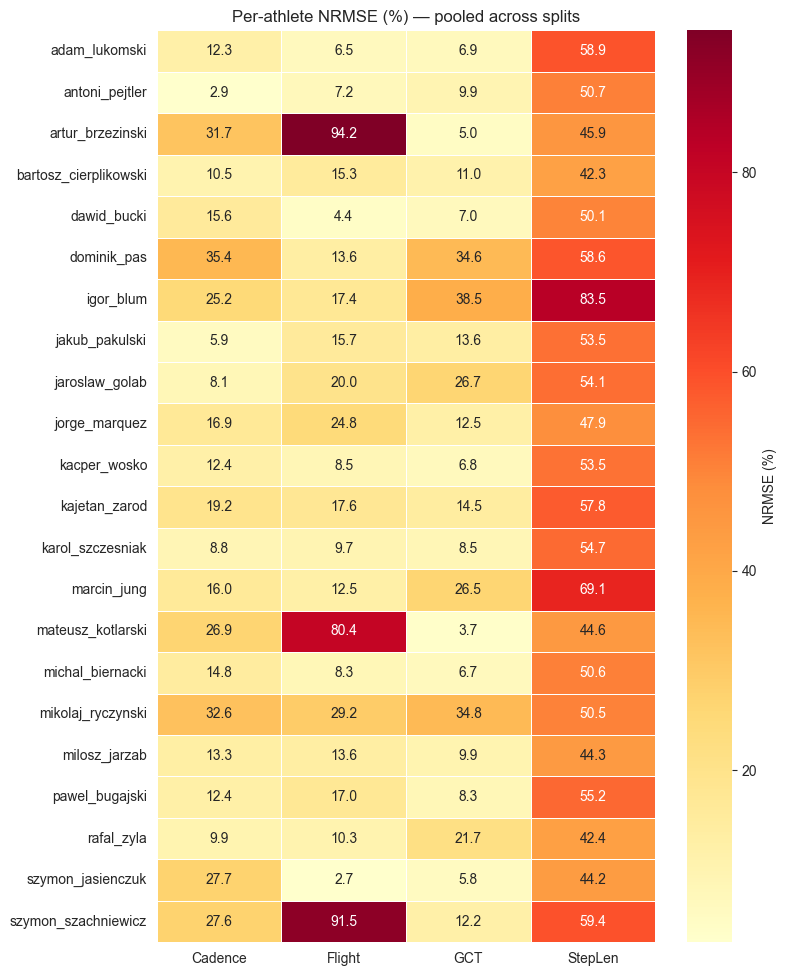

In [14]:
import seaborn as sns

_metric_defs = [
    ("mean_gct_s",         "mean_gct_s_oj",      "GCT"),
    ("mean_flight_s",      "mean_flight_s_oj",   "Flight"),
    ("mean_step_length_m", "mean_step_len_m_oj", "StepLen"),
    ("cadence_spm",        "cadence_spm_oj",     "Cadence"),
]

rows = []
for (athlete, split), g in merged.groupby(["athlete", "split"]):
    for video_col, optojump_col, label in _metric_defs:
        diff  = g[video_col] - g[optojump_col]
        rmse  = np.sqrt((diff**2).mean())
        bias  = diff.mean()
        nrmse = rmse / g[optojump_col].mean() * 100
        rows.append({"athlete": athlete, "split": split, "metric": label,
                     "n": len(g), "bias": bias, "RMSE": rmse, "NRMSE (%)": nrmse})

ath_err = pd.DataFrame(rows)

hm = ath_err.pivot_table(index="athlete", columns="metric",
                          values="NRMSE (%)", aggfunc="mean")

fig, ax = plt.subplots(figsize=(8, max(5, len(hm) * 0.38 + 1.5)))
sns.heatmap(hm, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
            linewidths=0.4, cbar_kws={"label": "NRMSE (%)"})
ax.set_title("Per-athlete NRMSE (%) — pooled across splits")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [15]:
TOP_N = 5
for metric_label in ["GCT", "Flight", "StepLen"]:
    print(f"\n── {metric_label}: {TOP_N} highest-error athletes ──")
    sub = ath_err[ath_err["metric"] == metric_label]
    for split in ['train']:
        worst = (sub[sub["split"] == split]
                 .nlargest(TOP_N, "NRMSE (%)")
                 [["athlete", "n", "bias", "RMSE", "NRMSE (%)"]])
        if worst.empty:
            continue
        print(f"  {split}:")
        print(worst.round(4).to_string(index=False, col_space=18))


── GCT: 5 highest-error athletes ──
  train:
           athlete                  n               bias               RMSE          NRMSE (%)
         igor_blum                  4            -0.0176             0.0543            38.4525
 mikolaj_ryczynski                  6            -0.0375             0.0613            34.8010
       dominik_pas                  6            -0.0321             0.0485            34.6190
    jaroslaw_golab                  4            -0.0282             0.0425            26.6585
       marcin_jung                  6            -0.0160             0.0420            26.4553

── Flight: 5 highest-error athletes ──
  train:
            athlete                  n               bias               RMSE          NRMSE (%)
   artur_brzezinski                  6            -0.0642             0.1592            94.2356
szymon_szachniewicz                  6            -0.0441             0.1293            91.4900
  mateusz_kotlarski                  6         

## Per-test-id error analysis

Heatmap shows NRMSE (%) per test_id and metric (train / test / all splits).
Bar chart compares Video vs. Optojump mean per test_id (pooled across athletes and studies).
Errors are sorted by NRMSE for each metric.

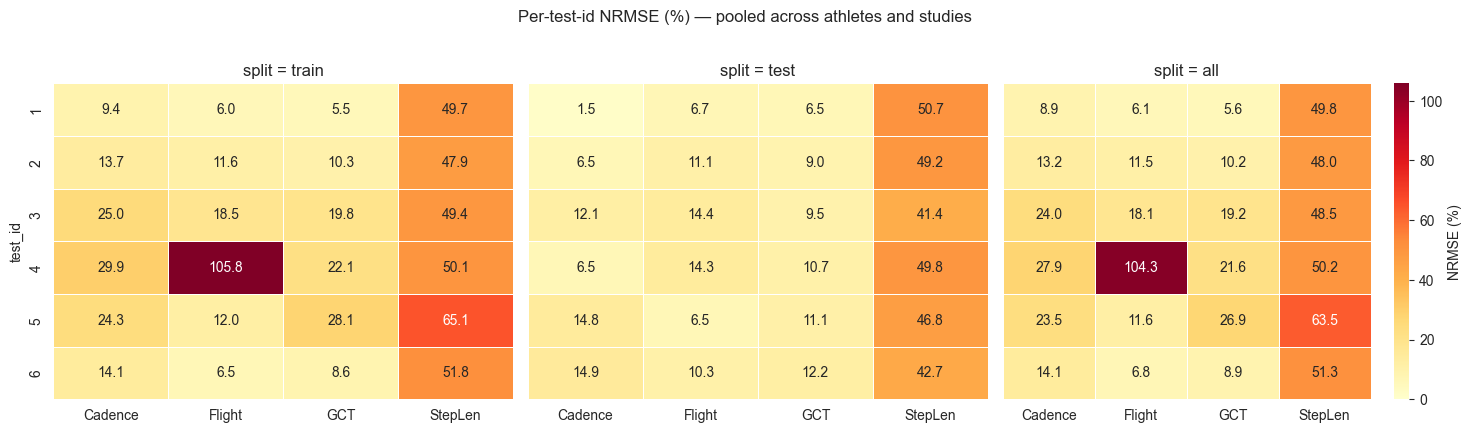

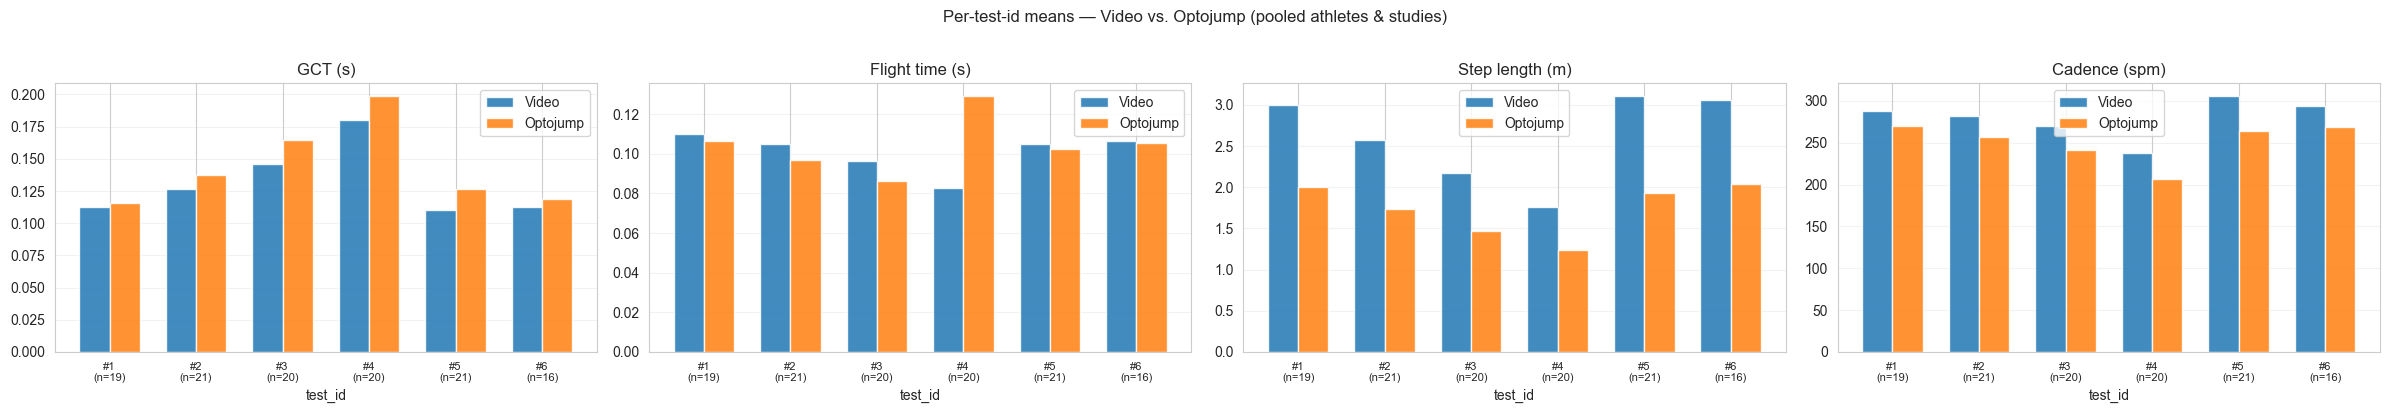

In [16]:
tid_rows = []
for (test_id, split), g in merged.groupby(["test_id", "split"]):
    for video_col, optojump_col, label in _metric_defs:
        diff = g[video_col] - g[optojump_col]
        rmse = np.sqrt((diff**2).mean())
        tid_rows.append({
            "test_id":   test_id,
            "split":     split,
            "metric":    label,
            "n":         len(g),
            "bias":      diff.mean(),
            "RMSE":      rmse,
            "NRMSE (%)": rmse / g[optojump_col].mean() * 100,
        })

for test_id, g in merged.groupby("test_id"):
    for video_col, optojump_col, label in _metric_defs:
        diff = g[video_col] - g[optojump_col]
        rmse = np.sqrt((diff**2).mean())
        tid_rows.append({
            "test_id":   test_id,
            "split":     "all",
            "metric":    label,
            "n":         len(g),
            "bias":      diff.mean(),
            "RMSE":      rmse,
            "NRMSE (%)": rmse / g[optojump_col].mean() * 100,
        })

tid_err = pd.DataFrame(tid_rows)

show_splits = [s for s in ["train", "test", "all"] if s in tid_err["split"].values]
fig, axes = plt.subplots(1, len(show_splits),
                          figsize=(5 * len(show_splits), max(4, merged["test_id"].nunique() * 0.45 + 1.5)),
                          sharey=True)
if len(show_splits) == 1:
    axes = [axes]

vmax = tid_err["NRMSE (%)"].max()
for ax, split in zip(axes, show_splits):
    hm = (tid_err[tid_err["split"] == split]
          .pivot_table(index="test_id", columns="metric", values="NRMSE (%)", aggfunc="mean")
          .sort_index())
    sns.heatmap(hm, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
                linewidths=0.4, vmin=0, vmax=vmax,
                cbar=(split == show_splits[-1]),
                cbar_kws={"label": "NRMSE (%)"})
    ax.set_title(f"split = {split}")
    ax.set_xlabel("")
    ax.set_ylabel("test_id" if split == show_splits[0] else "")

plt.suptitle("Per-test-id NRMSE (%) — pooled across athletes and studies", y=1.02)
plt.tight_layout()
plt.show()

# ── Bar chart: Video vs Optojump mean per test_id ────────────────────────────
test_ids = sorted(merged["test_id"].unique())
x = np.arange(len(test_ids))
w = 0.35

fig, axes = plt.subplots(1, len(METRICS), figsize=(6 * len(METRICS), 4))
for ax, (video_col, optojump_col, title, color) in zip(axes, METRICS):
    vid_means = [merged[merged["test_id"] == t][video_col].mean() for t in test_ids]
    oj_means  = [merged[merged["test_id"] == t][optojump_col].mean() for t in test_ids]
    ns        = [int((merged["test_id"] == t).sum()) for t in test_ids]
    ax.bar(x - w / 2, vid_means, w, label="Video",    color='C0',  alpha=0.85)
    ax.bar(x + w / 2, oj_means,  w, label="Optojump", color="C1", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f"#{t}\n(n={n})" for t, n in zip(test_ids, ns)], fontsize=8)
    ax.set_xlabel("test_id")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.25)

plt.suptitle("Per-test-id means — Video vs. Optojump (pooled athletes & studies)", y=1.02)
plt.tight_layout()
plt.show()

In [17]:
print("Per-test-id errors sorted by NRMSE — split = all:\n")
for metric_label in ["GCT", "Flight", "StepLen"]:
    sub = (tid_err[(tid_err["metric"] == metric_label) & (tid_err["split"] == "all")]
           .sort_values("NRMSE (%)", ascending=False)
           [["test_id", "n", "bias", "RMSE", "NRMSE (%)"]])
    print(f"  {metric_label}:")
    print(sub.round(4).to_string(index=False, col_space=12))
    print()

Per-test-id errors sorted by NRMSE — split = all:

  GCT:
     test_id            n         bias         RMSE    NRMSE (%)
           5           21      -0.0168       0.0340      26.9491
           4           20      -0.0182       0.0429      21.6124
           3           20      -0.0189       0.0316      19.2052
           2           21      -0.0108       0.0140      10.1532
           6           16      -0.0064       0.0105       8.8623
           1           19      -0.0037       0.0065       5.6145

  Flight:
     test_id            n         bias         RMSE    NRMSE (%)
           4           20      -0.0463       0.1347     104.3408
           3           20       0.0101       0.0156      18.0923
           5           21       0.0021       0.0119      11.5811
           2           21       0.0079       0.0112      11.5192
           6           16       0.0013       0.0071       6.7722
           1           19       0.0035       0.0065       6.0787

  StepLen:
     test

## Per-video highest errors
Absolute error between video prediction and Optojump for each individual recording, sorted largest first.

In [29]:
TOP_N_VIDEOS = 10

_vid_metric_defs = [
    ("mean_gct_s",         "mean_gct_s_oj",      "GCT (s)"),
    ("mean_flight_s",      "mean_flight_s_oj",   "Flight time (s)"),
    ("mean_step_length_m", "mean_step_len_m_oj", "Step length (m)"),
    ("cadence_spm",        "cadence_spm_oj",     "Cadence (spm)"),
]

for video_col, oj_col, label in _vid_metric_defs:
    sub = (
        merged
        .assign(
            error=(merged[video_col] - merged[oj_col]).abs(),
            diff= merged[video_col] - merged[oj_col],
        )
        .nlargest(TOP_N_VIDEOS, "error")
        [["athlete", "study_id", "test_id", "split", video_col, oj_col, "diff", "error"]]
        .rename(columns={video_col: "video", oj_col: "optojump"})
    )
    print(f"── {label}  top {TOP_N_VIDEOS} worst videos ──")
    print(sub.round(4).to_string(index=False))
    print()

── GCT (s)  top 10 worst videos ──
          athlete  study_id  test_id split  video  optojump    diff  error
mikolaj_ryczynski         1        4 train 0.1774    0.3167 -0.1394 0.1394
      dominik_pas         1        3 train 0.0458    0.1580 -0.1122 0.1122
        igor_blum         1        5 train 0.0958    0.1993 -0.1035 0.1035
      marcin_jung         1        5 train 0.1125    0.2149 -0.1024 0.1024
   jaroslaw_golab         1        4 train 0.1617    0.2441 -0.0825 0.0825
       rafal_zyla         1        4 train 0.1937    0.1282  0.0655 0.0655
mikolaj_ryczynski         1        3 train 0.1806    0.2262 -0.0457 0.0457
    kajetan_zarod         1        3 train 0.1458    0.1791 -0.0333 0.0333
    jorge_marquez         1        3 train 0.1583    0.1916 -0.0332 0.0332
        igor_blum         1        4 train 0.1900    0.1576  0.0324 0.0324

── Flight time (s)  top 10 worst videos ──
            athlete  study_id  test_id split  video  optojump    diff  error
   artur_brzezinski

## Error summary — bias vs. random, train / test breakdown

`systematic_ratio = |bias| / RMSE`:  1.0 = all errors have the same sign (purely systematic offset); 0.0 = errors cancel out (purely random).
Rule of thumb used here: ratio > 0.7 → **systematic**, ratio < 0.3 → **random**, otherwise → **mixed**.

In [19]:
def calculate_gait_metrics_summary(df, fps=None, quant_floor=None):
    """
    Computes a comprehensive biomechanical error summary for gait metrics.
    """
    metrics_spec = [
        ("mean_gct_s",         "mean_gct_s_oj",      "GCT",         "s"),
        ("mean_flight_s",      "mean_flight_s_oj",   "Flight time", "s"),
        ("mean_step_length_m", "mean_step_len_m_oj", "Step length", "m"),
        ("cadence_spm",        "cadence_spm_oj",     "Cadence",     "spm"),
    ]

    splits = [
        ("train", df["split"] == "train"),
        ("test",  df["split"] == "test"),
        ("all",   pd.Series(True, index=df.index)),
    ]

    summary_rows = []
    for split_label, mask in splits:
        sub = df[mask]
        if sub.empty: continue

        for v_col, oj_col, label, unit in metrics_spec:
            diff = sub[v_col] - sub[oj_col]
            bias = diff.mean()
            rmse = np.sqrt((diff**2).mean())
            std  = diff.std()
            nrmse = rmse / sub[oj_col].mean() * 100
            bias_pct = (bias / sub[oj_col].mean()) * 100
            correlation = sub[v_col].corr(sub[oj_col])

            sys_ratio = abs(bias) / rmse if rmse > 0 else 0.0
            error_type = ("systematic" if sys_ratio > 0.7 else
                          "random"     if sys_ratio < 0.3 else "mixed")

            summary_rows.append({
                "Split": split_label,
                "Metric": f"{label} ({unit})",
                "n": len(sub),
                "Video mean": round(sub[v_col].mean(), 4),
                "OJ mean": round(sub[oj_col].mean(), 4),
                "Bias": f"{bias:+.4f}",
                "Bias %": f"{bias_pct:+.1f}%",
                "RMSE": round(rmse, 4),
                "NRMSE": f"{nrmse:.1f}%",
                "STD": round(std, 4),
                "correlation": round(correlation, 3),
                "sys_ratio": round(sys_ratio, 2),
                "Error type": error_type,
            })

    summary_df = pd.DataFrame(summary_rows).set_index(["Split", "Metric"])

    frames_df = None
    if fps and quant_floor:
        frame_rows = []
        for (split, metric), row in summary_df.iterrows():
            if not metric.endswith("(s)"): continue

            rmse_frames = float(row["RMSE"]) * fps
            frame_rows.append({
                "Split": split,
                "Metric": metric,
                "RMSE (s)": row["RMSE"],
                "RMSE (frames)": round(rmse_frames, 2),
                "Floor (frames)": round(quant_floor, 2),
                "RMSE / Floor": round(rmse_frames / quant_floor, 1),
            })
        frames_df = pd.DataFrame(frame_rows).set_index(["Split", "Metric"])

    return summary_df, frames_df

In [20]:
fps = cfg.fps
quant_floor_frames = 1 / np.sqrt(6)

summary_df, frames_df = calculate_gait_metrics_summary(
    merged,
    fps=cfg.fps,
    quant_floor=quant_floor_frames
)
display(summary_df)

n  Video mean   OJ mean      Bias  Bias %     RMSE  \
Split Metric                                                                  
train GCT (s)          106      0.1329    0.1454   -0.0127   -8.8%   0.0284   
      Flight time (s)  106      0.1004    0.1053   -0.0050   -4.7%   0.0594   
      Step length (m)  106      2.5942    1.7205   +0.8743  +50.8%   0.9334   
      Cadence (spm)    106    279.2665  249.7074  +29.5591  +11.8%  49.9965   
test  GCT (s)           11      0.1235    0.1362   -0.0126   -9.3%   0.0135   
      Flight time (s)   11      0.1040    0.0950   +0.0090   +9.4%   0.0102   
      Step length (m)   11      2.5950    1.7685   +0.8265  +46.7%   0.8415   
      Cadence (spm)     11    279.7652  260.2188  +19.5464   +7.5%  26.6514   
all   GCT (s)          117      0.1320    0.1445   -0.0127   -8.8%   0.0273   
      Flight time (s)  117      0.1007    0.1043   -0.0036   -3.5%   0.0566   
      Step length (m)  117      2.5943    1.7250   +0.8698  +50.4%   0.9250   
      Cadence (spm)    117    279.3134  250.6957  +28.6177  +11.4%  48.2848   

                       NRMSE      STD  correlation  sys_ratio  Error type  
Split Metric                                                               
train GCT (s)          19.5%   0.0255        0.781       0.45       mixed  
      Flight time (s)  56.4%   0.0594        0.062       0.08      random  
      Step length (m)  54.2%   0.3282        0.862       0.94  systematic  
      Cadence (spm)    20.0%  40.5142        0.494       0.59       mixed  
test  GCT (s)           9.9%   0.0049        0.977       0.94  systematic  
      Flight time (s)  10.7%   0.0051        0.929       0.88  systematic  
      Step length (m)  47.6%   0.1661        0.976       0.98  systematic  
      Cadence (spm)    10.2%  19.0016        0.832       0.73  systematic  
all   GCT (s)          18.9%   0.0243        0.787       0.47       mixed  
      Flight time (s)  54.2%   0.0567        0.068       0.06      random  
      Step length (m)  53.6%   0.3162        0.867       0.94  systematic  
      Cadence (spm)    19.3%  39.0575        0.499       0.59       mixed

In [21]:
display(frames_df)

RMSE (s)  RMSE (frames)  Floor (frames)  RMSE / Floor
Split Metric                                                                
train GCT (s)            0.0284           3.41            0.41           8.3
      Flight time (s)    0.0594           7.13            0.41          17.5
test  GCT (s)            0.0135           1.62            0.41           4.0
      Flight time (s)    0.0102           1.22            0.41           3.0
all   GCT (s)            0.0273           3.28            0.41           8.0
      Flight time (s)    0.0566           6.79            0.41          16.6

---
## Upper bound: ground-truth labels vs. Optojump

Repeats the same error analysis using **manual annotation labels** instead of TCN predictions.
This shows the lowest achievable error given the video frame rate — any remaining gap between
`RMSE / Floor` and 1.0 is due to the 120 fps discretisation alone, not model mistakes.

In [22]:
gt_bio_df, gt_steps = make_bio_df(load_labels_annotations)

gt_merged = gt_bio_df.merge(oj_agg, on=["athlete", "study_id", "test_id"], how="inner")
gt_merged["split"] = gt_merged["video_path"].map(lambda vp: _manifest_idx.get(vp, {}).get("split", "unknown"))

gt_summary_df, gt_frames_df = calculate_gait_metrics_summary(
    gt_merged,
    fps=cfg.fps,
    quant_floor=quant_floor_frames
)

display(gt_summary_df)
display(gt_frames_df)

n  Video mean   OJ mean      Bias  Bias %     RMSE  \
Split Metric                                                                  
train GCT (s)          106      0.1316    0.1454   -0.0137   -9.5%   0.0254   
      Flight time (s)  106      0.0996    0.1053   -0.0057   -5.4%   0.0596   
      Step length (m)  106      2.5635    1.7205   +0.8430  +49.0%   0.8947   
      Cadence (spm)    106    271.4487  249.7074  +21.7413   +8.7%  55.0968   
test  GCT (s)           11      0.1248    0.1362   -0.0114   -8.4%   0.0128   
      Flight time (s)   11      0.1024    0.0950   +0.0074   +7.7%   0.0092   
      Step length (m)   11      2.6016    1.7685   +0.8331  +47.1%   0.8466   
      Cadence (spm)     11    279.7652  260.2188  +19.5464   +7.5%  26.6514   
all   GCT (s)          117      0.1310    0.1445   -0.0135   -9.4%   0.0245   
      Flight time (s)  117      0.0999    0.1043   -0.0045   -4.3%   0.0568   
      Step length (m)  117      2.5671    1.7250   +0.8421  +48.8%   0.8903   
      Cadence (spm)    117    272.2306  250.6957  +21.5349   +8.6%  53.0757   

                       NRMSE      STD  correlation  sys_ratio  Error type  
Split Metric                                                               
train GCT (s)          17.5%   0.0215        0.858       0.54       mixed  
      Flight time (s)  56.6%   0.0596        0.132       0.10      random  
      Step length (m)  52.0%   0.3012        0.871       0.94  systematic  
      Cadence (spm)    22.1%  50.8663        0.597       0.39       mixed  
test  GCT (s)           9.4%   0.0062        0.950       0.89  systematic  
      Flight time (s)   9.7%   0.0058        0.890       0.80  systematic  
      Step length (m)  47.9%   0.1580        0.981       0.98  systematic  
      Cadence (spm)    10.2%  19.0016        0.832       0.73  systematic  
all   GCT (s)          17.0%   0.0206        0.860       0.55       mixed  
      Flight time (s)  54.5%   0.0569        0.138       0.08      random  
      Step length (m)  51.6%   0.2903        0.876       0.95  systematic  
      Cadence (spm)    21.2%  48.7193        0.601       0.41       mixed

RMSE (s)  RMSE (frames)  Floor (frames)  RMSE / Floor
Split Metric                                                                
train GCT (s)            0.0254           3.05            0.41           7.5
      Flight time (s)    0.0596           7.15            0.41          17.5
test  GCT (s)            0.0128           1.54            0.41           3.8
      Flight time (s)    0.0092           1.10            0.41           2.7
all   GCT (s)            0.0245           2.94            0.41           7.2
      Flight time (s)    0.0568           6.82            0.41          16.7

## Raw vs postprocessed label comparison
For each video, counts the number and fraction of frames where the raw model output differs from the postprocessed output. High values indicate noisy model predictions on that recording.

In [23]:
from src.gait.detection.detectors import (
    _foot_contact_mask,
    _LEFT_HEEL_DY, _LEFT_HEEL_Y, _RIGHT_HEEL_DY, _RIGHT_HEEL_Y,
)


def _kin_raw_labels(rec):
    """Kinematic labels before min_duration_filter."""
    T  = len(rec.features)
    ts = np.arange(T) / cfg.fps * 1000.0
    lc = _foot_contact_mask(rec.features[:, _LEFT_HEEL_DY],  ts, T, cfg.fps, 200.0)
    rc = _foot_contact_mask(rec.features[:, _RIGHT_HEEL_DY], ts, T, cfg.fps, 200.0)
    ly, ry = rec.features[:, _LEFT_HEEL_Y], rec.features[:, _RIGHT_HEEL_Y]
    out = np.full(T, 2, dtype=np.int64)
    out[lc & ~rc] = 0
    out[rc & ~lc] = 1
    cf = lc & rc
    out[cf & (ly >= ry)] = 0
    out[cf & (ry >  ly)] = 1
    return out


diff_rows = []
for rec, _ in pairs:
    sid, tid = _study_test(rec.video_path)
    T = len(rec.labels)

    if LABEL_SOURCE == "tcn":
        entry = (_manifest_idx or {}).get(rec.video_path)
        if entry is None:
            continue
        probs = np.load(entry["probs_path"])
        if len(probs) != T:
            probs = probs[:T] if len(probs) > T else np.pad(probs, ((0, T - len(probs)), (0, 0)), "edge")
        raw = probs.argmax(axis=1).astype(np.int64)
        pp  = smooth_probs_argmax(probs, window=POSTPROCESS_WIN)

    elif LABEL_SOURCE == "xgb":
        if _xgb_detector is None:
            continue
        feats = rec.features[:, XGB_FEATURE_IDX]
        proba = _xgb_detector.clf.predict_proba(feats)
        raw = proba.argmax(axis=1).astype(np.int64)
        pp  = smooth_probs_argmax(proba, window=POSTPROCESS_WIN)

    elif LABEL_SOURCE == "kinematic":
        raw = _kin_raw_labels(rec)
        pp  = KinematicDetector().predict(rec.features, cfg.fps)

    else:  # annotations — no postprocessing step
        continue

    n      = len(raw)
    n_diff = int((raw != pp).sum())
    diff_rows.append({
        "athlete":     rec.athlete,
        "study_id":    sid,
        "test_id":     tid,
        "n_frames":    n,
        "n_changed":   n_diff,
        "pct_changed": round(n_diff / n * 100, 2) if n else 0.0,
    })

diff_df = (
    pd.DataFrame(diff_rows)
    .sort_values("pct_changed", ascending=False)
    .reset_index(drop=True)
)

n_any = (diff_df["n_changed"] > 0).sum()
print(f"Label source: {LABEL_SOURCE!r}  |  postprocessing window: {POSTPROCESS_WIN}")
print(f"Videos with any raw → postprocessed change: {n_any} / {len(diff_df)}")
if len(diff_df):
    print(f"Mean % frames changed: {diff_df['pct_changed'].mean():.2f}%")
    print(f"Max  % frames changed: {diff_df['pct_changed'].max():.2f}%\n")
display(diff_df)

Label source: 'tcn'  |  postprocessing window: 3
Videos with any raw → postprocessed change: 76 / 176
Mean % frames changed: 0.67%
Max  % frames changed: 5.88%



,athlete,study_id,test_id,n_frames,n_changed,pct_changed
0,pawel_bugajski,2,5,51,3,5.88
1,jorge_marquez,2,5,82,4,4.88
2,pawel_bugajski,1,1,66,3,4.55
3,mikolaj_ryczynski,1,5,71,3,4.23
4,pawel_bugajski,2,4,50,2,4.00
...,...,...,...,...,...,...
171,szymon_szachniewicz,1,2,99,0,0.00
172,szymon_szachniewicz,1,1,91,0,0.00
173,szymon_jasienczuk,1,2,93,0,0.00
174,rafal_zyla,1,6,98,0,0.00


---
## Joint angles — per-video mean trajectories

Plots the mean knee, ankle, and torso angles across all frames for each video.

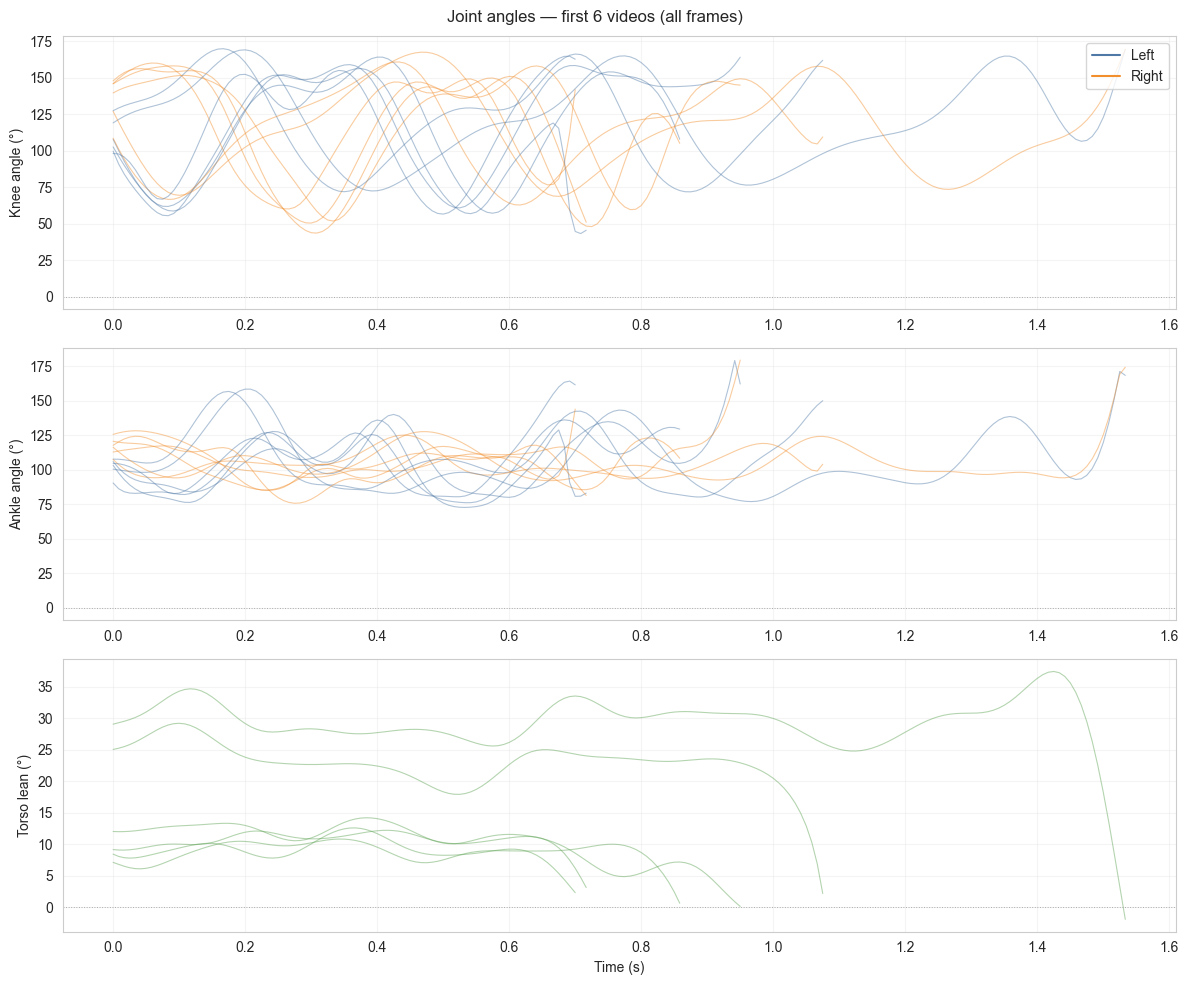

In [24]:
# Compute joint angles for a sample of records (first 6 for brevity)
SAMPLE_N = 6  # TODO: mark detected landings/takeoffs on the plots label them with the angle values; find a table with some generalized values for these metrics;

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
angle_cols = [
    (["left_knee_angle", "right_knee_angle"], "Knee angle (°)", axes[0]),
    (["left_ankle_angle", "right_ankle_angle"], "Ankle angle (°)", axes[1]),
    (["torso_lean"], "Torso lean (°)", axes[2]),
]
side_colors = {"left": "#4e79a7", "right": "#f28e2b", "torso": "#59a14f"}

for rec, pose_df in pairs[:SAMPLE_N]:
    angles = compute_joint_angles(pose_df)
    t = np.arange(len(angles)) / cfg.fps  # seconds

    for cols, ylabel, ax in angle_cols:
        for col in cols:
            side = col.split("_")[0] if "_" in col else "torso"
            ax.plot(
                t,
                angles[col],
                alpha=0.45,
                linewidth=0.8,
                color=side_colors.get(side, "#aaa"),
                label=f"{rec.athlete} {col}" if rec == pairs[0][0] else None,
            )

for cols, ylabel, ax in angle_cols:
    ax.set_ylabel(ylabel)
    ax.axhline(0, color="#aaa", linewidth=0.7, linestyle=":")
    ax.grid(alpha=0.2)

axes[2].set_xlabel("Time (s)")
# Manual legend for sides
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color=side_colors["left"], label="Left"),
    Line2D([0], [0], color=side_colors["right"], label="Right"),
]
axes[0].legend(handles=legend_elements, loc="upper right")
plt.suptitle(f"Joint angles — first {SAMPLE_N} videos (all frames)")
plt.tight_layout()
plt.show()

---
## Per-step distributions

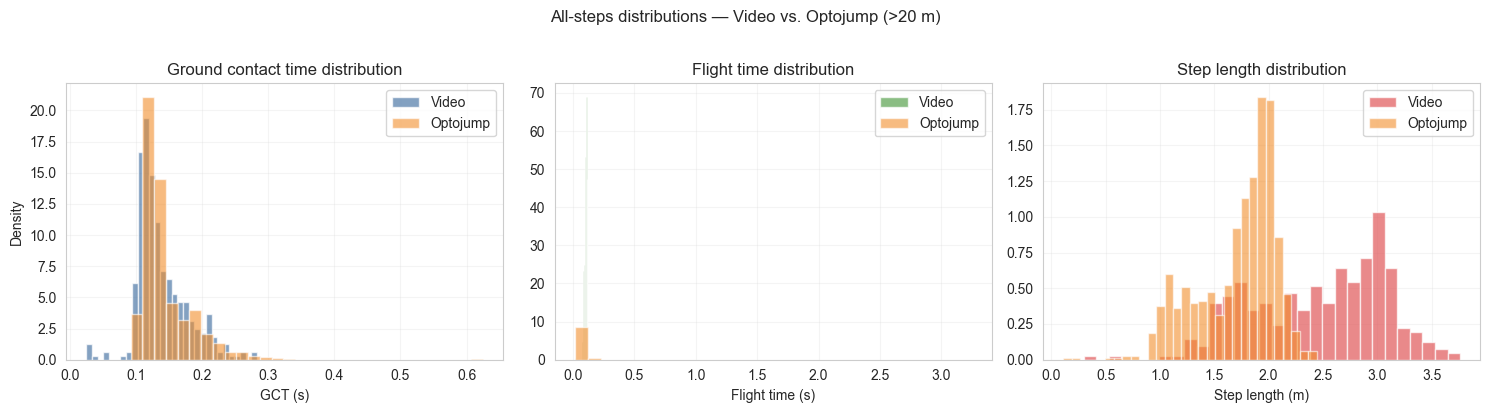

All-step means:
  GCT        — Video: 0.1387 s   Optojump: 0.1442 s
  Flight     — Video: 0.0995 s   Optojump: 0.1058 s
  Step len   — Video: 2.4633 m   Optojump: 1.7200 m


In [25]:
contact_df = pd.DataFrame(contact_all)
flight_df = pd.DataFrame(flight_all)
step_len_df = pd.DataFrame(step_len_all)

oj_steps_post20 = oj_post20.copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# GCT
ax = axes[0]
if len(contact_df):
    ax.hist(
        contact_df["contact_s"],
        bins=30,
        alpha=0.7,
        color="#4e79a7",
        label="Video",
        density=True,
    )
ax.hist(
    oj_steps_post20["contact_time"].dropna(),
    bins=30,
    alpha=0.6,
    color="#f28e2b",
    label="Optojump",
    density=True,
)
ax.set_xlabel("GCT (s)")
ax.set_ylabel("Density")
ax.set_title("Ground contact time distribution")
ax.legend()
ax.grid(alpha=0.2)

# Flight time
ax = axes[1]
if len(flight_df):
    ax.hist(
        flight_df["flight_s"],
        bins=30,
        alpha=0.7,
        color="#59a14f",
        label="Video",
        density=True,
    )
ax.hist(
    oj_steps_post20["flight_time"].dropna(),
    bins=30,
    alpha=0.6,
    color="#f28e2b",
    label="Optojump",
    density=True,
)
ax.set_xlabel("Flight time (s)")
ax.set_title("Flight time distribution")
ax.legend()
ax.grid(alpha=0.2)

# Step length
ax = axes[2]
if len(step_len_df):
    ax.hist(
        step_len_df["step_length_m"].dropna(),
        bins=30,
        alpha=0.7,
        color="#e15759",
        label="Video",
        density=True,
    )
ax.hist(
    oj_steps_post20["step_length_m_oj"].dropna(),
    bins=30,
    alpha=0.6,
    color="#f28e2b",
    label="Optojump",
    density=True,
)
ax.set_xlabel("Step length (m)")
ax.set_title("Step length distribution")
ax.legend()
ax.grid(alpha=0.2)

plt.suptitle("All-steps distributions — Video vs. Optojump (>20 m)", y=1.02)
plt.tight_layout()
plt.show()

# Print means
print("All-step means:")
if len(contact_df):
    print(
        f"  GCT        — Video: {contact_df['contact_s'].mean():.4f} s   "
        f"Optojump: {oj_steps_post20['contact_time'].mean():.4f} s"
    )
if len(flight_df):
    print(
        f"  Flight     — Video: {flight_df['flight_s'].mean():.4f} s   "
        f"Optojump: {oj_steps_post20['flight_time'].mean():.4f} s"
    )
if len(step_len_df):
    print(
        f"  Step len   — Video: {step_len_df['step_length_m'].mean():.4f} m   "
        f"Optojump: {oj_steps_post20['step_length_m_oj'].mean():.4f} m"
    )